# Hierarchical Clustering of 10 Recipes

Agglomerative clustering with complete linkage on 10 sample recipes. TFIDF vectors are reduced to 2 PCA dimensions, pairwise distances feed the linkage, and the dendrogram shows which recipes merge first.

In [1]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("dark_background")
BG = "#0F172A"; AMBER = "#F59E0B"; TEAL = "#14B8A6"; INK = "#E2E8F0"; RED = "#EF4444"
plt.rcParams.update({"figure.facecolor": BG, "axes.facecolor": BG,
                     "savefig.facecolor": BG, "text.color": INK,
                     "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK})

recipes = pd.read_csv("../data/RAW_recipes_processed.csv")
ingredients = recipes["ingredients"].dropna()
print("recipes loaded:", recipes.shape[0])

from sklearn.feature_extraction.text import TfidfVectorizer

def vectorize(texts, ngram_range=(1, 2), max_features=1000):
    vec = TfidfVectorizer(max_df=0.5, max_features=max_features, min_df=2,
                          stop_words="english", ngram_range=ngram_range, use_idf=True)
    return vec.fit_transform(texts), vec
from sklearn.decomposition import PCA
X10, _ = vectorize(ingredients.values[:10])
coords10 = PCA(n_components=2).fit_transform(X10.toarray())
names10 = recipes["name"].iloc[:10].tolist()
for i, n in enumerate(names10):
    print(i, n)

recipes loaded: 10000
0 arriba   baked winter squash mexican style
1 a bit different  breakfast pizza
2 all in the kitchen  chili
3 alouette  potatoes
4 amish  tomato ketchup  for canning
5 apple a day  milk shake
6 aww  marinated olives
7 backyard style  barbecued ribs
8 bananas 4 ice cream  pie
9 beat this  banana bread


In [2]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
Z = linkage(pdist(coords10), method="complete")
print("linkage rows: [group a, group b, merge distance, group size]")
print(np.round(Z, 4))

linkage rows: [group a, group b, merge distance, group size]
[[ 5.      8.      0.0973  2.    ]
 [ 0.      6.      0.1146  2.    ]
 [ 1.      4.      0.1283  2.    ]
 [ 9.     11.      0.2469  3.    ]
 [ 7.     12.      0.2766  3.    ]
 [ 3.     14.      0.3928  4.    ]
 [ 2.     15.      0.6183  5.    ]
 [13.     16.      1.2051  8.    ]
 [10.     17.      1.2188 10.    ]]


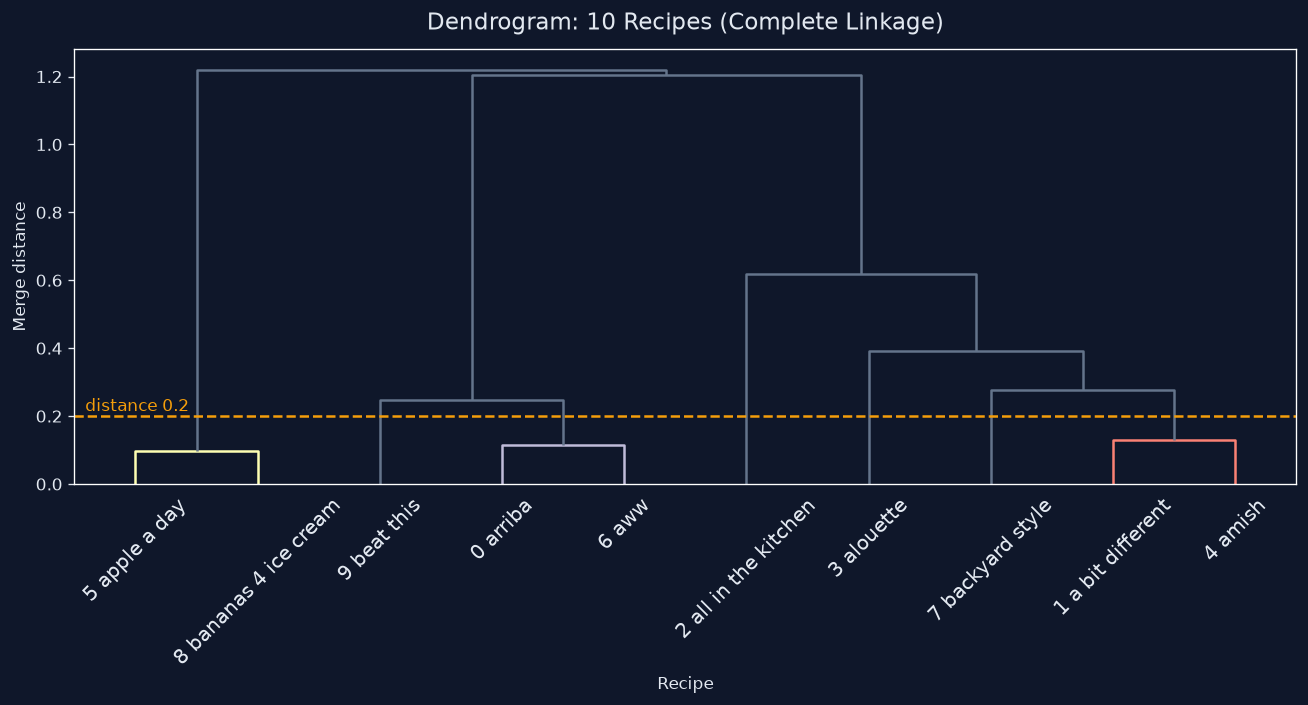

In [3]:
short = [n.split("  ")[0][:22] for n in names10]
fig, ax = plt.subplots(figsize=(11, 6))
dendrogram(Z, labels=[f"{i} {s}" for i, s in enumerate(short)], ax=ax,
           color_threshold=0.2, above_threshold_color="#64748B", leaf_rotation=45)
ax.set_title("Dendrogram: 10 Recipes (Complete Linkage)", fontsize=14, pad=12)
ax.set_xlabel("Recipe")
ax.set_ylabel("Merge distance")
ax.axhline(0.2, color=AMBER, linestyle="--", linewidth=1.5)
ax.text(9.4, 0.215, "distance 0.2", color=AMBER, fontsize=10, ha="right")
fig.tight_layout()
fig.savefig("../charts/chart_dendrogram.png", dpi=120)

In [4]:
def rlabel(i):
    i = int(i)
    return names10[i] if i < 10 else "merged group"

close_pairs = [(rlabel(a), rlabel(b), d) for a, b, d, _ in Z if d < 0.2]
print("recipe pairs merged below distance 0.2:")
for x, y, d in close_pairs:
    print(f"{d:.4f}   {x}  <>  {y}")

recipe pairs merged below distance 0.2:
0.0973   apple a day  milk shake  <>  bananas 4 ice cream  pie
0.1146   arriba   baked winter squash mexican style  <>  aww  marinated olives
0.1283   a bit different  breakfast pizza  <>  amish  tomato ketchup  for canning


## Findings

* Three pairs merge below distance 0.2. They are the most similar recipes in the sample.
* Closest pair: the two desserts, apple a day milk shake and bananas 4 ice cream pie, at distance 0.10.
* Next: arriba baked winter squash mexican style with aww marinated olives at 0.11.
* Then: a bit different breakfast pizza with amish tomato ketchup for canning at 0.13.
* Everything else merges much later, which the dendrogram makes visible at a glance.